<a href="https://colab.research.google.com/github/mvaraujo1977/TechCahllenge_Tireoide/blob/marceloviana/model_tireoide.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de Classificação de Hipotireoidismo

Este notebook apresenta o desenvolvimento de um pipeline de Machine Learning para a detecção de hipotireoidismo utilizando o dataset da UCI.

## 1. Etapas do Projeto

*   **Carregamento e Limpeza:** Importação dos dados e aplicação de nomes às colunas baseados no arquivo `.names`.
*   **Tratamento de Dados Ausentes:**
    *   Remoção da coluna `TBG` (mais de 90% nula).
    *   Imputação de valores numéricos pela mediana e categóricos pela moda.
*   **Pré-processamento:**
    *   Codificação de variáveis binárias (`f/t`, `y/n`, `M/F`).
    *   Codificação da variável alvo (`hypothyroid` vs `negative`).
    *   Escalonamento (StandardScaler) das variáveis numéricas contínuas.
*   **Análise de Dados:** Visualização da correlação entre variáveis e distribuição das classes (dataset desbalanceado).

## 2. Modelos Comparados

Foram implementados e avaliados dois modelos principais:

1.  **Regressão Logística:**
    *   Utilizada como modelo de linha de base (baseline).
    *   Configurada com `class_weight='balanced'` para lidar com o desequilíbrio de classes.
    *   Oferece interpretabilidade através dos coeficientes das variáveis.

2.  **Random Forest Classifier:**
    *   Modelo baseado em árvores de decisão que lida bem com relações não-lineares.
    *   Apresentou o melhor desempenho geral.

## 3. Resultados e Avaliação

*   **Métrica Principal:** F1-Score (escolhida por considerar tanto precisão quanto recall em dados desbalanceados).
*   **Melhor Modelo:** O **Random Forest** obteve um F1-score superior (~0.99), demonstrando alta eficácia na identificação de pacientes doentes com o mínimo de falsos positivos.
*   **Importância de Variáveis:** As variáveis relacionadas ao TSH e FTI foram identificadas como os indicadores mais críticos para a previsão em ambos os modelos.

In [2]:
import pandas as pd

df = pd.read_csv("hypothyroid.data", header=None)

print(df.head())
print(df.shape)

            0   1  2  3  4  5  6  7  8  9   ... 16    17 18  19 20    21 22  \
0  hypothyroid  72  M  f  f  f  f  f  f  f  ...  y  0.60  y  15  y  1.48  y   
1  hypothyroid  15  F  t  f  f  f  f  f  f  ...  y  1.70  y  19  y  1.13  y   
2  hypothyroid  24  M  f  f  f  f  f  f  f  ...  y  0.20  y   4  y     1  y   
3  hypothyroid  24  F  f  f  f  f  f  f  f  ...  y  0.40  y   6  y  1.04  y   
4  hypothyroid  77  M  f  f  f  f  f  f  f  ...  y  1.20  y  57  y  1.28  y   

   23 24 25  
0  10  n  ?  
1  17  n  ?  
2   0  n  ?  
3   6  n  ?  
4  44  n  ?  

[5 rows x 26 columns]
(3163, 26)


In [3]:
import pandas as pd

# Carregando o arquivo principal
# Geralmente esses datasets vêm em partes (.data e .test),
# mas como temos o 'hypothyroid.data', vamos garantir que ele esteja bem estruturado.
df = pd.read_csv('hypothyroid.data', header=None, na_values='?')

# Se houver outro arquivo de dados similar, você pode concatená-los assim:
# df2 = pd.read_csv('outro_arquivo.data', header=None, na_values='?')
# df_final = pd.concat([df, df2], ignore_index=True)

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {df.shape}")
print(df.head())

Dataset carregado com sucesso!
Formato do dataset: (3163, 26)
            0     1  2  3  4  5  6  7  8  9   ... 16   17 18    19 20    21  \
0  hypothyroid  72.0  M  f  f  f  f  f  f  f  ...  y  0.6  y  15.0  y  1.48   
1  hypothyroid  15.0  F  t  f  f  f  f  f  f  ...  y  1.7  y  19.0  y  1.13   
2  hypothyroid  24.0  M  f  f  f  f  f  f  f  ...  y  0.2  y   4.0  y  1.00   
3  hypothyroid  24.0  F  f  f  f  f  f  f  f  ...  y  0.4  y   6.0  y  1.04   
4  hypothyroid  77.0  M  f  f  f  f  f  f  f  ...  y  1.2  y  57.0  y  1.28   

  22    23 24  25  
0  y  10.0  n NaN  
1  y  17.0  n NaN  
2  y   0.0  n NaN  
3  y   6.0  n NaN  
4  y  44.0  n NaN  

[5 rows x 26 columns]


In [4]:
import os

file_data = 'hypothyroid.data'
file_test = 'hypothyroid.test'

# Carrega o primeiro arquivo
df1 = pd.read_csv(file_data, header=None, na_values='?')

# Tenta carregar o segundo arquivo se existir
if os.path.exists(file_test):
    df2 = pd.read_csv(file_test, header=None, na_values='?')
    df_final = pd.concat([df1, df2], ignore_index=True)
    print(f"Arquivos combinados! Novo formato: {df_final.shape}")
else:
    df_final = df1
    print("Apenas o arquivo .data foi encontrado. df_final criado.")

print(df_final.head())

Apenas o arquivo .data foi encontrado. df_final criado.
            0     1  2  3  4  5  6  7  8  9   ... 16   17 18    19 20    21  \
0  hypothyroid  72.0  M  f  f  f  f  f  f  f  ...  y  0.6  y  15.0  y  1.48   
1  hypothyroid  15.0  F  t  f  f  f  f  f  f  ...  y  1.7  y  19.0  y  1.13   
2  hypothyroid  24.0  M  f  f  f  f  f  f  f  ...  y  0.2  y   4.0  y  1.00   
3  hypothyroid  24.0  F  f  f  f  f  f  f  f  ...  y  0.4  y   6.0  y  1.04   
4  hypothyroid  77.0  M  f  f  f  f  f  f  f  ...  y  1.2  y  57.0  y  1.28   

  22    23 24  25  
0  y  10.0  n NaN  
1  y  17.0  n NaN  
2  y   0.0  n NaN  
3  y   6.0  n NaN  
4  y  44.0  n NaN  

[5 rows x 26 columns]


In [5]:
import re

names_file = 'hypothyroid.names'

column_names = []

if os.path.exists(names_file):
    with open(names_file, 'r') as f:
        lines = f.readlines()

    # Tenta encontrar a linha que define as classes (primeira coluna)
    # No dataset hypothyroid, a primeira coluna geralmente é o alvo
    column_names.append('target')

    # Procura por padrões como 'nome_da_coluna: tipo.' no arquivo .names
    for line in lines:
        match = re.search(r'^([a-zA-Z0-9_ \-]+):', line)
        if match:
            col_name = match.group(1).strip().replace(' ', '_')
            if col_name not in column_names:
                column_names.append(col_name)

# Se conseguimos extrair nomes, aplicamos ao dataframe
if len(column_names) == len(df_final.columns):
    df_final.columns = column_names
    print("Nomes das colunas aplicados com sucesso!")
else:
    print(f"Aviso: Encontrados {len(column_names)} nomes para {len(df_final.columns)} colunas.")
    # Fallback manual baseado na estrutura padrão do dataset Hypothyroid da UCI
    uci_columns = [
        'target', 'age', 'sex', 'on_thyroxine', 'query_on_thyroxine',
        'on_antithyroid_medication', 'sick', 'pregnant', 'thyroid_surgery',
        'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid', 'lithium',
        'goitre', 'tumor', 'hypopituitary', 'psych', 'TSH_measured', 'TSH',
        'T3_measured', 'T3', 'TT4_measured', 'TT4', 'T4U_measured', 'T4U',
        'FTI_measured', 'FTI', 'TBG_measured', 'TBG', 'referral_source'
    ]
    if len(df_final.columns) <= len(uci_columns):
        df_final.columns = uci_columns[:len(df_final.columns)]
        print("Colunas aplicadas usando mapeamento padrão UCI.")

display(df_final.head(15))

Nomes das colunas aplicados com sucesso!


,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN
5,hypothyroid,85.0,F,f,f,f,f,t,f,f,...,y,1.1,y,27.0,y,1.19,y,23.0,n,NaN
6,hypothyroid,64.0,F,f,f,f,t,f,f,f,...,y,1.3,y,54.0,y,0.86,y,63.0,n,NaN
7,hypothyroid,72.0,F,f,f,f,f,f,f,f,...,y,1.9,y,34.0,y,1.05,y,32.0,n,NaN
8,hypothyroid,20.0,F,f,f,f,f,t,f,f,...,n,NaN,y,39.0,y,1.21,y,32.0,n,NaN
9,hypothyroid,42.0,F,f,f,f,f,f,f,f,...,n,NaN,y,7.6,y,1.02,y,7.5,n,NaN


In [6]:
df_final

,target,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,...,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,y,0.6,y,15.0,y,1.48,y,10.0,n,NaN
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,y,1.7,y,19.0,y,1.13,y,17.0,n,NaN
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,y,0.2,y,4.0,y,1.00,y,0.0,n,NaN
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,y,0.4,y,6.0,y,1.04,y,6.0,n,NaN
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,y,1.2,y,57.0,y,1.28,y,44.0,n,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,negative,58.0,F,f,f,f,f,f,f,f,...,y,1.7,y,86.0,y,0.91,y,95.0,n,NaN
3159,negative,29.0,F,f,f,f,f,f,f,f,...,y,1.8,y,99.0,y,1.01,y,98.0,n,NaN
3160,negative,77.0,M,f,f,f,f,f,f,f,...,y,0.6,y,71.0,y,0.68,y,104.0,n,NaN
3161,negative,74.0,F,f,f,f,f,f,f,f,...,y,0.1,y,65.0,y,0.48,y,137.0,n,NaN


In [8]:
from google.colab import files

# Nome do arquivo de saída
output_filename = 'hypothyroid_final.csv'

# Salva o dataframe como CSV
df_final.to_csv(output_filename, index=False)

print(f'Arquivo {output_filename} gerado com sucesso! Iniciando download...')

# Faz o download do arquivo para o seu computador
#files.download(output_filename)

Arquivo hypothyroid_final.csv gerado com sucesso! Iniciando download...


In [9]:
print('Verificando valores nulos por coluna:')
print(df_final.isnull().sum())

print('\nTotal de valores nulos no dataset:')
print(df_final.isnull().sum().sum())

Verificando valores nulos por coluna:
target                          0
age                           446
sex                            73
on_thyroxine                    0
query_on_thyroxine              0
on_antithyroid_medication       0
thyroid_surgery                 0
query_hypothyroid               0
query_hyperthyroid              0
pregnant                        0
sick                            0
tumor                           0
lithium                         0
goitre                          0
TSH_measured                    0
TSH                           468
T3_measured                     0
T3                            695
TT4_measured                    0
TT4                           249
T4U_measured                    0
T4U                           248
FTI_measured                    0
FTI                           247
TBG_measured                    0
TBG                          2903
dtype: int64

Total de valores nulos no dataset:
5329


### Tratamento de Valores Nulos

Com base na análise anterior, a coluna 'TBG' possui um número muito elevado de valores nulos (mais de 90%), o que a torna inviável para imputação significativa. Portanto, ela será descartada.

Para colunas categóricas como 'sex', a imputação será feita com a moda (valor mais frequente). Para as colunas numéricas ('age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI'), a imputação será realizada com a mediana, que é mais robusta a outliers do que a média.

In [10]:
# 1. Descartar a coluna 'TBG' devido à alta porcentagem de valores nulos
df_final = df_final.drop(columns=['TBG'])
print("Coluna 'TBG' descartada.")

# 2. Imputar 'sex' com a moda
if 'sex' in df_final.columns:
    df_final['sex'].fillna(df_final['sex'].mode()[0], inplace=True)
    print("Valores nulos da coluna 'sex' imputados com a moda.")

# 3. Imputar colunas numéricas com a mediana
numeric_cols_to_impute = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
for col in numeric_cols_to_impute:
    if col in df_final.columns:
        df_final[col].fillna(df_final[col].median(), inplace=True)
        print(f"Valores nulos da coluna '{col}' imputados com a mediana.")

print('\nTratamento de valores nulos concluído. Verificando novamente:')
print(df_final.isnull().sum())

Coluna 'TBG' descartada.
Valores nulos da coluna 'sex' imputados com a moda.
Valores nulos da coluna 'age' imputados com a mediana.
Valores nulos da coluna 'TSH' imputados com a mediana.
Valores nulos da coluna 'T3' imputados com a mediana.
Valores nulos da coluna 'TT4' imputados com a mediana.
Valores nulos da coluna 'T4U' imputados com a mediana.
Valores nulos da coluna 'FTI' imputados com a mediana.

Tratamento de valores nulos concluído. Verificando novamente:
target                       0
age                          0
sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
thyroid_surgery              0
query_hypothyroid            0
query_hyperthyroid           0
pregnant                     0
sick                         0
tumor                        0
lithium                      0
goitre                       0
TSH_measured                 0
TSH                          0
T3_measured                  0
T3  

/tmp/ipykernel_1948/978473488.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['sex'].fillna(df_final['sex'].mode()[0], inplace=True)
/tmp/ipykernel_1948/978473488.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

Com o tratamento dos valores nulos, o dataset está pronto para as próximas etapas de pré-processamento, como a codificação de variáveis categóricas e o escalonamento de variáveis numéricas, se necessário.

### Codificação de Variáveis Categóricas

Nesta etapa, vamos transformar as variáveis categóricas em formatos numéricos que os algoritmos de Machine Learning podem processar.

In [11]:
# Identificar colunas binárias e outras categóricas
binary_cols_ft = ['on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
                  'thyroid_surgery', 'query_hypothyroid', 'query_hyperthyroid',
                  'pregnant', 'sick', 'tumor', 'lithium', 'goitre']
binary_cols_yn = ['TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured', 'TBG_measured']

# Mapear 'f' para 0 e 't' para 1 para colunas binárias 'f'/'t' e preencher NaNs com 0
for col in binary_cols_ft:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str).str.strip().str.lower().map({'f': 0, 't': 1}).fillna(0)
        print(f"Coluna '{col}' codificada (f=0, t=1) e NaNs preenchidos com 0.")

# Mapear 'y' para 1 e 'n' para 0 para colunas binárias 'y'/'n' e preencher NaNs com 0
for col in binary_cols_yn:
    if col in df_final.columns:
        df_final[col] = df_final[col].astype(str).str.strip().str.lower().map({'n': 0, 'y': 1}).fillna(0)
        print(f"Coluna '{col}' codificada (n=0, y=1) e NaNs preenchidos com 0.")

# Codificar a coluna 'sex' (M/F) e preencher NaNs com 0 (representando 'F') se existirem novos NaNs pós-mapeamento
if 'sex' in df_final.columns:
    df_final['sex'] = df_final['sex'].astype(str).str.strip().str.upper().map({'M': 1, 'F': 0}).fillna(0)
    print("Coluna 'sex' codificada (M=1, F=0) e NaNs preenchidos com 0.")

print('\nVerificando o tipo de dados após a codificação:')
print(df_final.head())

Coluna 'on_thyroxine' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'query_on_thyroxine' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'on_antithyroid_medication' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'thyroid_surgery' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'query_hypothyroid' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'query_hyperthyroid' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'pregnant' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'sick' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'tumor' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'lithium' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'goitre' codificada (f=0, t=1) e NaNs preenchidos com 0.
Coluna 'TSH_measured' codificada (n=0, y=1) e NaNs preenchidos com 0.
Coluna 'T3_measured' codificada (n=0, y=1) e NaNs preenchidos com 0.
Coluna 'TT4_measured' codificada (n=0, y=1) e NaNs preenchidos com 0.
Coluna 'T4U_measur

A coluna 'target' é a variável dependente. Por agora, vamos apenas ver os valores únicos e, se necessário, codificá-la mais tarde, dependendo do tipo de problema (classificação binária ou multiclasse).

In [12]:
if 'target' in df_final.columns:
    print(f"Valores únicos na coluna 'target': {df_final['target'].unique()}")

# Verificar o tipo de dados de todas as colunas para garantir que estão numéricas onde deveriam
print('\nTipos de dados atualizados:')
print(df_final.info())

Valores únicos na coluna 'target': ['hypothyroid' 'negative']

Tipos de dados atualizados:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   target                     3163 non-null   object 
 1   age                        3163 non-null   float64
 2   sex                        3163 non-null   int64  
 3   on_thyroxine               3163 non-null   int64  
 4   query_on_thyroxine         3163 non-null   int64  
 5   on_antithyroid_medication  3163 non-null   int64  
 6   thyroid_surgery            3163 non-null   int64  
 7   query_hypothyroid          3163 non-null   int64  
 8   query_hyperthyroid         3163 non-null   int64  
 9   pregnant                   3163 non-null   int64  
 10  sick                       3163 non-null   int64  
 11  tumor                      3163 non-null   int64  
 12  lithium      

### Codificação da Variável Alvo (`target`)

Vamos codificar a variável alvo 'target' para um formato numérico, já que é uma variável categórica binária. 'hypothyroid' será mapeado para 1 e 'negative' para 0.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Inicializar o LabelEncoder
le = LabelEncoder()

# Ajustar e transformar a coluna 'target'
df_final['target'] = le.fit_transform(df_final['target'])

print("Valores únicos na coluna 'target' após a codificação:")
print(df_final['target'].unique())
print("Mapeamento do LabelEncoder:")
for i, item in enumerate(le.classes_):
    print(f"  {item} -> {i}")

print('\nTipos de dados atualizados após a codificação do target:')
print(df_final.info())

Valores únicos na coluna 'target' após a codificação:
[0 1]
Mapeamento do LabelEncoder:
  hypothyroid -> 0
  negative -> 1

Tipos de dados atualizados após a codificação do target:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   target                     3163 non-null   int64  
 1   age                        3163 non-null   float64
 2   sex                        3163 non-null   int64  
 3   on_thyroxine               3163 non-null   int64  
 4   query_on_thyroxine         3163 non-null   int64  
 5   on_antithyroid_medication  3163 non-null   int64  
 6   thyroid_surgery            3163 non-null   int64  
 7   query_hypothyroid          3163 non-null   int64  
 8   query_hyperthyroid         3163 non-null   int64  
 9   pregnant                   3163 non-null   int64  
 10  sick                       3163 non

Com a variável alvo codificada, o dataset está agora totalmente numérico e pronto para as próximas etapas, como a separação entre features (X) e target (y), escalonamento de features e divisão em conjuntos de treino e teste.

### Separação de Features (X) e Target (y)

Nesta etapa, dividiremos o dataset em features (variáveis de entrada) e a variável alvo (a que queremos prever).

In [14]:
# Separar as features (X) da variável alvo (y)
X = df_final.drop('target', axis=1)
y = df_final['target']

print("Shape das features (X):", X.shape)
print("Shape do target (y):", y.shape)

print('\nPrimeiras 5 linhas das features (X):')
display(X.head())

print('\nPrimeiras 5 linhas do target (y):')
display(y.head())

Shape das features (X): (3163, 24)
Shape do target (y): (3163,)

Primeiras 5 linhas das features (X):


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,sick,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured
0,72.0,1,0,0,0,0,0,0,0,0,...,30.0,1,0.6,1,15.0,1,1.48,1,10.0,0
1,15.0,0,1,0,0,0,0,0,0,0,...,145.0,1,1.7,1,19.0,1,1.13,1,17.0,0
2,24.0,1,0,0,0,0,0,0,0,0,...,0.0,1,0.2,1,4.0,1,1.00,1,0.0,0
3,24.0,0,0,0,0,0,0,0,0,0,...,430.0,1,0.4,1,6.0,1,1.04,1,6.0,0
4,77.0,1,0,0,0,0,0,0,0,0,...,7.3,1,1.2,1,57.0,1,1.28,1,44.0,0



Primeiras 5 linhas do target (y):


,target
0,0
1,0
2,0
3,0
4,0


### Escalonamento de Features Numéricas

Vamos padronizar as features numéricas para que todas tenham média zero e variância unitária. Isso ajuda algoritmos de Machine Learning a convergirem mais rápido e a terem um desempenho melhor, especialmente aqueles baseados em distância.

In [15]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Identificar colunas numéricas para escalonamento
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Excluir colunas binárias que já foram codificadas e não precisam ser escalonadas
# (e.g., sex, on_thyroxine, TSH_measured, etc.)
# Podemos considerar que as colunas 'age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI' são as que realmente precisam de escalonamento

# Filtrar apenas as colunas que identificamos como numéricas contínuas para escalonar
# Estas são as colunas que normalmente se beneficiam mais do escalonamento
columns_to_scale = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

# Garantir que as colunas existem no DataFrame X
columns_to_scale = [col for col in columns_to_scale if col in X.columns]

# Inicializar o StandardScaler
scaler = StandardScaler()

# Aplicar o escalonamento apenas às colunas numéricas contínuas
X_scaled_numeric = scaler.fit_transform(X[columns_to_scale])

# Criar um DataFrame com as colunas escalonadas
X_scaled_df = pd.DataFrame(X_scaled_numeric, columns=columns_to_scale, index=X.index)

# Combinar as colunas escalonadas com as colunas não escalonadas (binárias/categóricas)
# Primeiro, remover as colunas numéricas originais de X
X_other_cols = X.drop(columns=columns_to_scale)

# Em seguida, concatenar com as colunas escalonadas
X_processed = pd.concat([X_other_cols, X_scaled_df], axis=1)

# GARANTIR QUE NENHUM NaN PERMANEÇA EM X_PROCESSED
X_processed = X_processed.fillna(0)

print("Features numéricas escalonadas com sucesso!")
print("Primeiras 5 linhas das features processadas (X_processed):")
display(X_processed.head())

Features numéricas escalonadas com sucesso!
Primeiras 5 linhas das features processadas (X_processed):


,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,thyroid_surgery,query_hypothyroid,query_hyperthyroid,pregnant,sick,tumor,...,TT4_measured,T4U_measured,FTI_measured,TBG_measured,age,TSH,T3,TT4,T4U,FTI
0,1,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1.141734,1.122672,-1.483836,-2.140310,2.313337,-1.809839
1,0,1,0,0,0,0,0,0,0,0,...,1,1,1,0,-2.041459,6.318212,-0.236955,-2.048715,0.704388,-1.688885
2,1,0,0,0,0,0,0,0,0,0,...,1,1,1,0,-1.538849,-0.232686,-1.937247,-2.392197,0.106779,-1.982629
3,0,0,0,0,0,0,0,0,0,0,...,1,1,1,0,-1.538849,19.194114,-1.710542,-2.346399,0.290659,-1.878955
4,1,0,0,0,0,0,0,0,0,0,...,1,1,1,0,1.420961,0.097118,-0.803719,-1.178560,1.393938,-1.222352


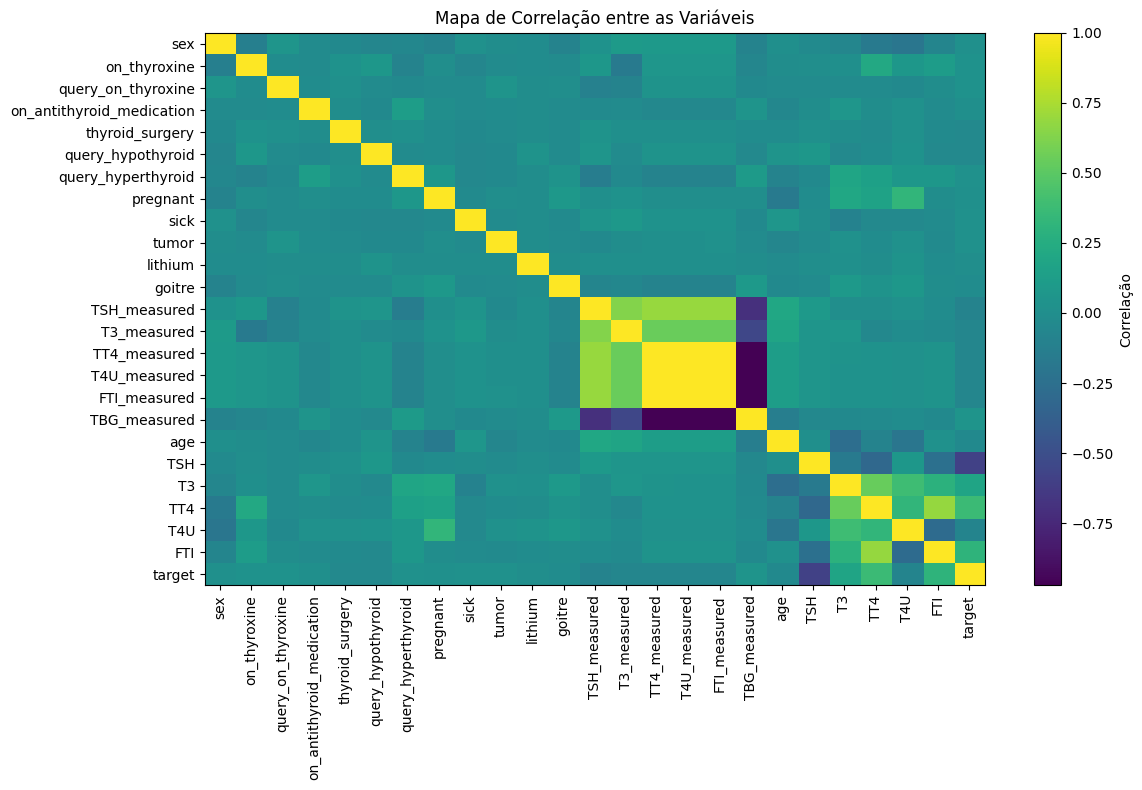

In [16]:
# =========================
# MAPA DE CORRELAÇÃO
# =========================

import matplotlib.pyplot as plt

df_corr = X_processed.copy()
df_corr['target'] = y

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar(label='Correlação')

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title('Mapa de Correlação entre as Variáveis')
plt.tight_layout()
plt.show()

### Divisão em Conjuntos de Treino e Teste

Agora vamos dividir o dataset `X_processed` e `y` em conjuntos de treino e teste. O conjunto de treino será usado para treinar o modelo, e o conjunto de teste para avaliar seu desempenho em dados não vistos.

In [28]:
from sklearn.model_selection import train_test_split

# Definir o tamanho do conjunto de teste (por exemplo, 20% dos dados)
test_size = 0.2
# Definir um random_state para reprodutibilidade dos resultados
random_state = 42

# Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=test_size, random_state=random_state, stratify=y)

print(f"Shape do X_train: {X_train.shape}")
print(f"Shape do X_test: {X_test.shape}")
print(f"Shape do y_train: {y_train.shape}")
print(f"Shape do y_test: {y_test.shape}")

print('\nContagem de classes em y_train:')
print(y_train.value_counts(normalize=True))
print('\nContagem de classes em y_test:')
print(y_test.value_counts(normalize=True))

Shape do X_train: (2530, 24)
Shape do X_test: (633, 24)
Shape do y_train: (2530,)
Shape do y_test: (633,)

Contagem de classes em y_train:
target
1    0.952174
0    0.047826
Name: proportion, dtype: float64

Contagem de classes em y_test:
target
1    0.952607
0    0.047393
Name: proportion, dtype: float64


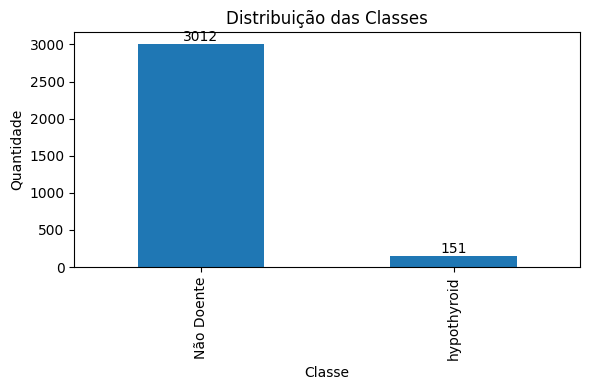

In [31]:
import matplotlib.pyplot as plt

# Mapear valores
y_named = y.map({
    0: 'hypothyroid',
    1: 'Não Doente'
})

# Contagem
class_counts = y_named.value_counts()

# Gráfico
plt.figure(figsize=(6,4))
class_counts.plot(kind='bar')

plt.title('Distribuição das Classes')
plt.xlabel('Classe')
plt.ylabel('Quantidade')

# Mostrar valores nas barras
for i, v in enumerate(class_counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

# Treinar Regressão Logística
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train, y_train)

# Previsão
y_pred_log = log_model.predict(X_test)

# Avaliação básica
print("F1-score Regressão Logística:", f1_score(y_test, y_pred_log, pos_label=0))
print(classification_report(
    y_test,
    y_pred_log,
    target_names=['Doente', 'Não Doente']
))

F1-score Regressão Logística: 0.7
              precision    recall  f1-score   support

      Doente       0.56      0.93      0.70        30
  Não Doente       1.00      0.96      0.98       603

    accuracy                           0.96       633
   macro avg       0.78      0.95      0.84       633
weighted avg       0.98      0.96      0.97       633



Matriz de Confusão - Regressão Logística:


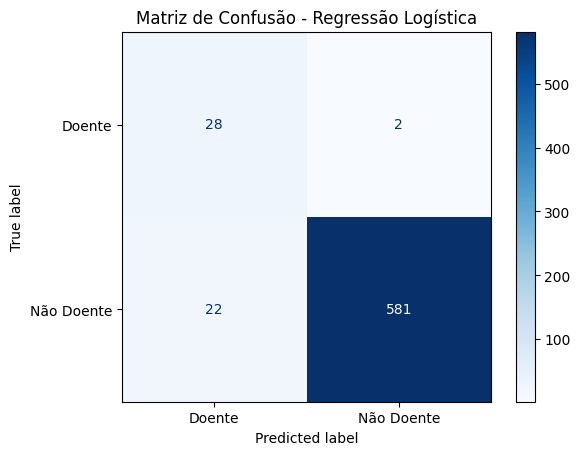

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gerar a Matriz de Confusão para a Regressão Logística
print("Matriz de Confusão - Regressão Logística:")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=['Doente', 'Não Doente'],
    cmap='Blues'
)

plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

Top 10 features mais importantes (Regressão Logística):


,feature,coef,abs_coef
23,FTI,2.436162,2.436162
21,TT4,2.135777,2.135777
12,TSH_measured,-1.100702,1.100702
3,on_antithyroid_medication,1.049761,1.049761
19,TSH,-0.770714,0.770714
11,goitre,-0.757920,0.757920
4,thyroid_surgery,-0.754554,0.754554
1,on_thyroxine,0.704253,0.704253
22,T4U,-0.652461,0.652461
5,query_hypothyroid,-0.494799,0.494799


<Figure size 1000x600 with 0 Axes>

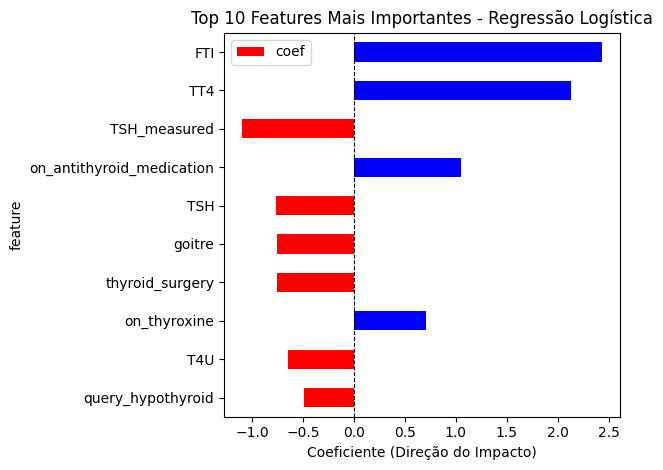

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pegar coeficientes
coef = log_model.coef_[0]

# Criar DataFrame
feat_importance_log = pd.DataFrame({
    'feature': X_train.columns,
    'coef': coef,
    'abs_coef': np.abs(coef)
})

# Ordenar por importância (valor absoluto)
feat_importance_log = feat_importance_log.sort_values(by='abs_coef', ascending=False)

print("Top 10 features mais importantes (Regressão Logística):")
display(feat_importance_log.head(10))

top10 = feat_importance_log.head(10).copy()

# Inverter para visualização (mais importante no topo do gráfico de barras horizontais)
top10 = top10.sort_values(by='abs_coef', ascending=True)

plt.figure(figsize=(10, 6))
top10.plot(
    x='feature',
    y='coef',
    kind='barh',
    color=['red' if c < 0 else 'blue' for c in top10['coef']]
)

plt.title('Top 10 Features Mais Importantes - Regressão Logística')
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Coeficiente (Direção do Impacto)')
plt.tight_layout()
plt.show()

In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regressão Logística
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Modelo 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

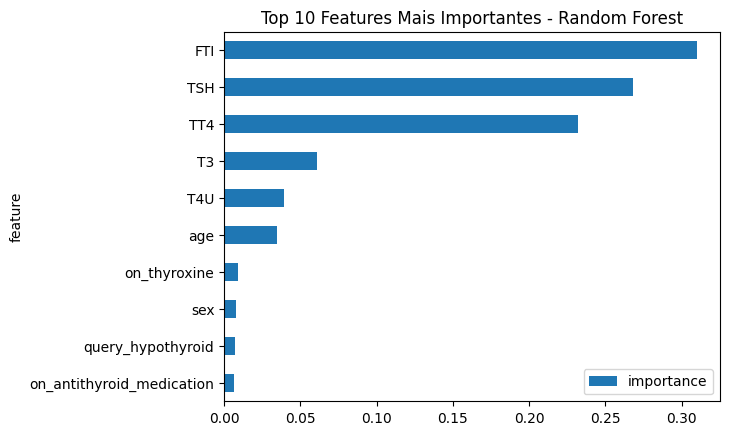

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# Cálculo das importâncias
importances = rf_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Visualização
feat_imp.head(10).plot(
    x='feature',
    y='importance',
    kind='barh'
)

plt.title('Top 10 Features Mais Importantes - Random Forest')
plt.gca().invert_yaxis()
plt.show()

Matriz de Confusão - Random Forest:


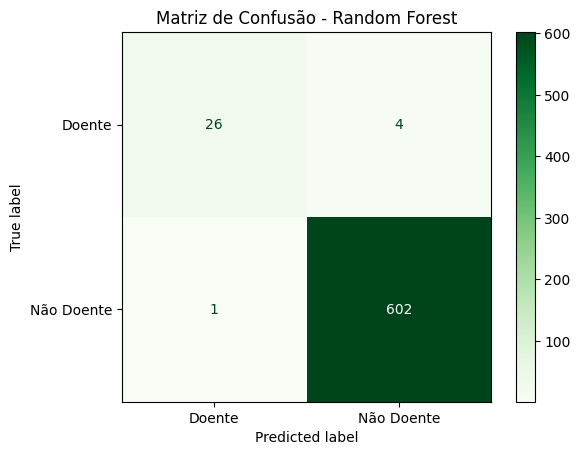

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Gerar a Matriz de Confusão para o Random Forest
print("Matriz de Confusão - Random Forest:")
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['Doente', 'Não Doente'],
    cmap='Greens'
)

plt.title('Matriz de Confusão - Random Forest')
plt.show()

In [50]:
from sklearn.metrics import classification_report, f1_score

# Gerar previsões para o Random Forest (que estava faltando)
y_pred_rf = rf_model.predict(X_test)

# Calcular F1-scores
f1_log = f1_score(y_test, y_pred_log, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print(f"F1-score Regressão Logística: {f1_log:.4f}")
print(f"F1-score Random Forest: {f1_rf:.4f}")

print("\nRelatório Regressão Logística:")
print(classification_report(y_test, y_pred_log, target_names=['Doente', 'Não Doente']))

print("\nRelatório Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Doente', 'Não Doente']))

F1-score Regressão Logística: 0.9798
F1-score Random Forest: 0.9959

Relatório Regressão Logística:
              precision    recall  f1-score   support

      Doente       0.56      0.93      0.70        30
  Não Doente       1.00      0.96      0.98       603

    accuracy                           0.96       633
   macro avg       0.78      0.95      0.84       633
weighted avg       0.98      0.96      0.97       633


Relatório Random Forest:
              precision    recall  f1-score   support

      Doente       0.96      0.87      0.91        30
  Não Doente       0.99      1.00      1.00       603

    accuracy                           0.99       633
   macro avg       0.98      0.93      0.95       633
weighted avg       0.99      0.99      0.99       633



In [51]:
if f1_rf > f1_log:
    melhor_modelo = "Random Forest"
else:
    melhor_modelo = "Regressão Logística"

print(f"\nMelhor modelo com base no F1-score: {melhor_modelo}")


Melhor modelo com base no F1-score: Random Forest
